In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import phik
from phik import resources
import warnings
warnings.filterwarnings("ignore")


Задание 1

1.Базово изучите датасет (достаточно методов info() и describe()).
2.Выдвиньте пару гипотез, например, “Верно ли, что чем выше ВВП, тем выше и уровень счастья?” или “Есть ли взаимосвязь между уровнем доверия правительству и уровнем счастья?”. 3.3.3.Постарайтесь подтвердить или опровергнуть их визуально и с помощью расчётов.
4.Составьте корреляционную матрицу всех числовых признаков набора данных и визуализируйте её с помощью тепловой карты.

In [3]:
df = pd.read_csv('happines_corruption.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 792 entries, 0 to 791
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            792 non-null    str    
 1   happiness_score    792 non-null    float64
 2   gdp_per_capita     792 non-null    float64
 3   family             792 non-null    float64
 4   health             792 non-null    float64
 5   freedom            792 non-null    float64
 6   generosity         792 non-null    float64
 7   government_trust   792 non-null    float64
 8   dystopia_residual  792 non-null    float64
 9   continent          792 non-null    str    
 10  Year               792 non-null    int64  
 11  social_support     792 non-null    float64
 12  cpi_score          792 non-null    int64  
dtypes: float64(9), int64(2), str(2)
memory usage: 80.6 KB


In [4]:
df.describe()

,happiness_score,gdp_per_capita,family,health,freedom,generosity,government_trust,dystopia_residual,Year,social_support,cpi_score
count,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000
mean,5.473310,0.929217,0.504998,0.648691,0.427016,0.212440,0.125720,1.379277,2017.500000,0.609302,44.327020
std,1.124726,0.385774,0.552736,0.232261,0.148003,0.121660,0.109032,1.075276,1.708904,0.640754,19.508833
min,2.566900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015.000000,0.000000,11.000000
25%,4.590750,0.644242,0.000000,0.510070,0.325433,0.125784,0.052862,0.000000,2016.000000,0.000000,30.000000
50%,5.485500,0.994544,0.000000,0.685397,0.439621,0.197000,0.089000,1.731948,2017.500000,0.176214,38.000000
75%,6.300500,1.228677,1.040410,0.815641,0.546280,0.273250,0.154250,2.236894,2019.000000,1.268250,57.000000
max,7.808700,2.096000,1.610574,1.141000,0.724000,0.838075,0.551910,3.602140,2020.000000,1.644000,91.000000


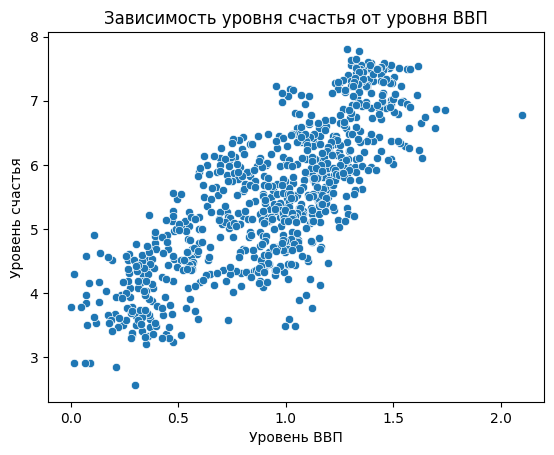

Статистика: 0.7932671770333466, p-value: 2.136725666280754e-172
Отвергаем нулевую гипотезу, существует зависимость между уровнем счастья и уровнем ВВП.


In [11]:
# H0 - Уровень счастья не зависит от уровня ВВП
# H1 - Уровень счастья зависит от уровня ВВП

sns.scatterplot(x='gdp_per_capita', y='happiness_score', data=df)
plt.title('Зависимость уровня счастья от уровня ВВП')
plt.xlabel('Уровень ВВП')
plt.ylabel('Уровень счастья')
plt.show()

stat, p = stats.pearsonr(df['gdp_per_capita'], df['happiness_score'])
print(f"Статистика: {stat}, p-value: {p}")
if p < 0.05:
    print("Отвергаем нулевую гипотезу, существует зависимость между уровнем счастья и уровнем ВВП.")
else:
    print("Не отвергаем нулевую гипотезу, нет достаточных доказательств зависимости между уровнем счастья и уровнем ВВП.")



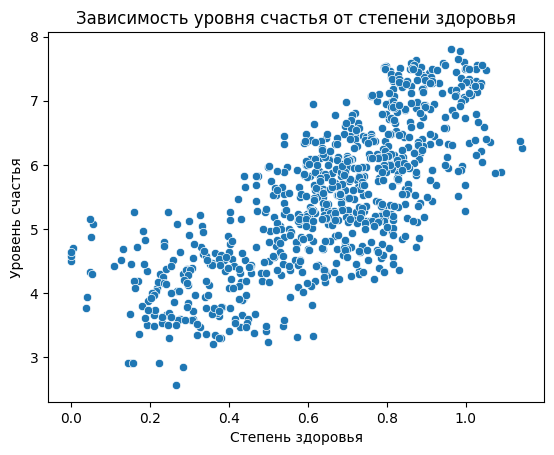

Статистика: 0.7535343457737051, p-value: 4.627963190846063e-146
Отвергаем нулевую гипотезу, существует зависимость между уровнем счастья и степенью здоровья.


In [16]:
# H0 - Степень здоровья не зависит от уровня счастья
# H1 - Степень здоровья зависит от уровня счастья

sns.scatterplot(x='health', y='happiness_score', data=df)
plt.title('Зависимость уровня счастья от степени здоровья')
plt.xlabel('Степень здоровья')
plt.ylabel('Уровень счастья')
plt.show()

stat, p = stats.pearsonr(df['health'], df['happiness_score'])
print(f"Статистика: {stat}, p-value: {p}")
if p < 0.05:
    print("Отвергаем нулевую гипотезу, существует зависимость между уровнем счастья и степенью здоровья.")
else:
    print("Не отвергаем нулевую гипотезу, нет достаточных доказательств зависимости между уровнем счастья и степенью здоровья.")



interval columns not set, guessing: ['happiness_score', 'gdp_per_capita', 'family', 'health', 'freedom', 'generosity', 'government_trust', 'dystopia_residual', 'Year', 'social_support', 'cpi_score']


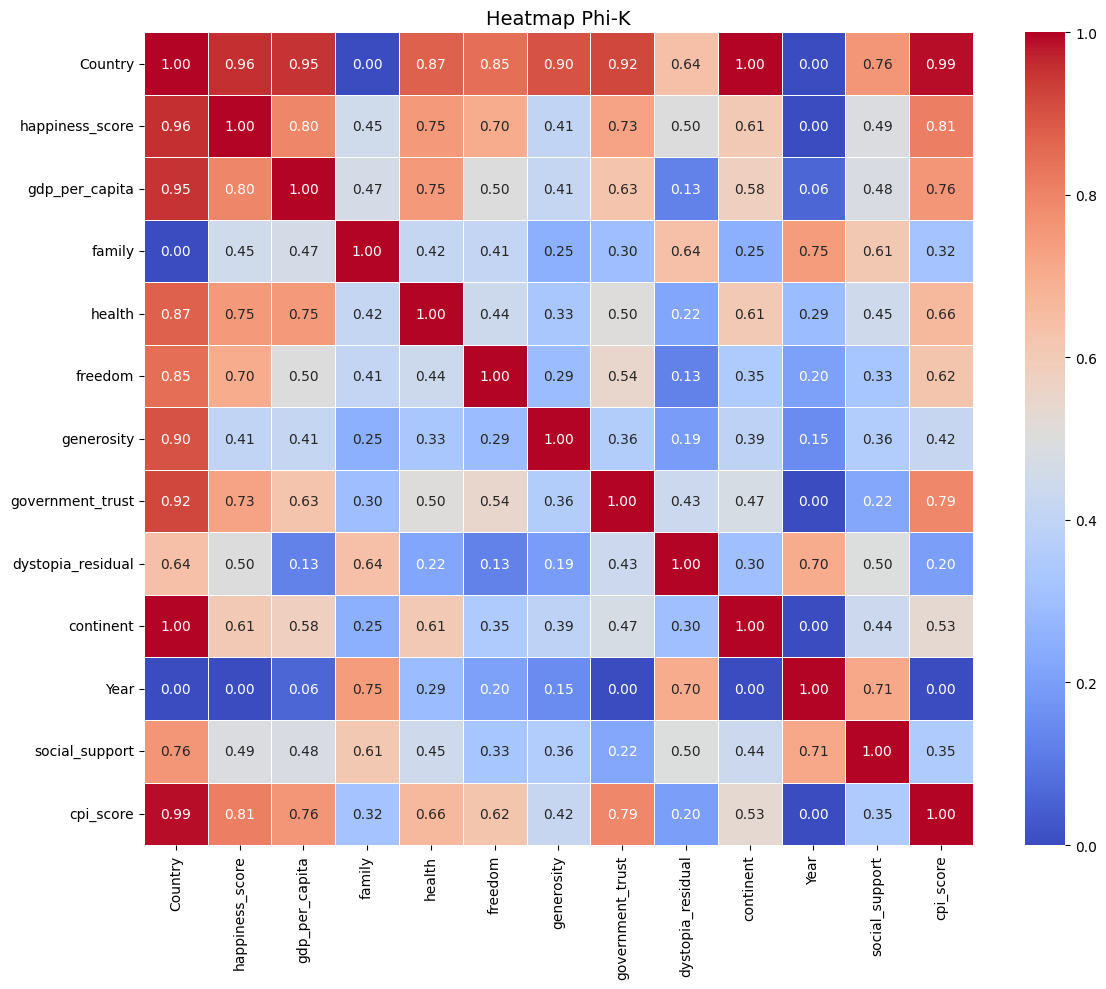

In [ ]:
phi_k_corr_matrix = df.phik_matrix()

plt.figure(figsize=(12, 10))
sns.heatmap(phi_k_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Phi-K', fontsize=14)
plt.tight_layout()
plt.show()

#В процессе вычисления и построения графиков видно, что корреляция между уровнем счастья и уровнем ВВП достаточно сильная, что подтверждается как визуально на scatterplot, так и статистически через тест Пирсона.
#Корреляция между уровнем счастья и степенью здоровья также присутствует, но она слабее, чем с уровнем ВВП. Это может указывать на то, что хотя здоровье влияет на счастье, другие факторы, такие как экономическое благополучие, могут играть более значительную роль в определении уровня счастья.

Задание 2
1.Оставьте только два столбца:'Temperature' и 'Sum'.
2.Постройте диаграмму рассеяния.
3.Постройте модель линейной регрессии для выбранных признаков.
4.Рассчитайте точность модели на тестовой выборке.
5.Выведите график остатков.
В этом задании нужно окончательно ответить на вопрос:
Есть ли связь между среднемесячной температурой и потреблением газа в Южной Корее?

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [18]:
fdf = pd.read_csv('gas_sales_data.csv')
df = fdf[['Temperature', 'Sum']]
df.head()

,Temperature,Sum
0,-1.20,1717175
1,-0.99,1766341
2,6.64,1490537
3,12.11,1096964
4,17.59,790248


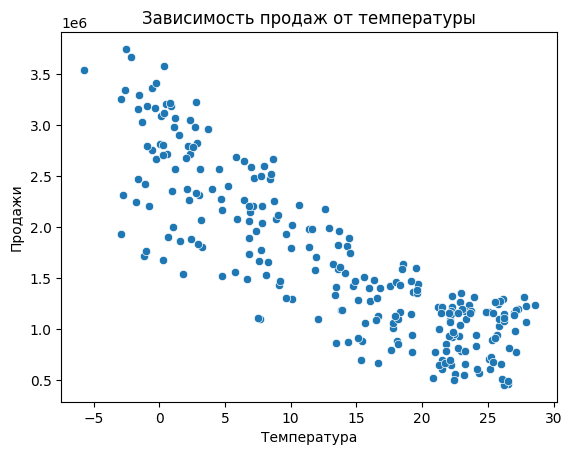

In [ ]:
sns.scatterplot(x='Temperature', y='Sum', data=df)
plt.title('Зависимость продаж от температуры')
plt.xlabel('Температура')
plt.ylabel('Продажи')
plt.show()
#По графику явно видно зависимость между температурой и продажами, что может указывать на то, что продажи уменьшаются с повышением температуры. Это может быть связано с тем, что в жаркую погоду люди меньше покупают газ, возможно, из-за снижения потребности в отоплении

R^2: 0.7287426116055771


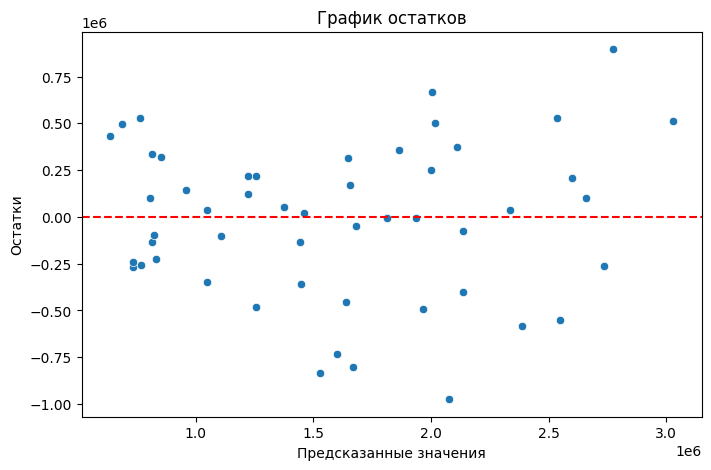

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df[['Temperature']], df['Sum'], test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R^2: {r2}")

#R^2: 0.73 - это означает, что модель объясняет 73% вариации в данных, что указывает на хорошую подгонку модели к данным. Это подтверждает визуальную зависимость между температурой и продажами, которую мы наблюдали на графике.

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('График остатков')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.show()

#График остатков показывает, что остатки распределены случайным образом вокруг нуля, что является хорошим признаком для линейной модели. Это указывает на то, что модель не имеет систематических ошибок и хорошо подходит для данных.